In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [3]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    feature_names = X.columns
    return feature_names

In [4]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    
    # permute the ordering of the examples
    # random inds every running 
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

## default parameters

In [35]:
X,Y = LoadData("X_data.csv","Y_data.csv")
feature_names = GetFeatureNames("X_data.csv")
running_num = 40
for i in range(running_num):
    acc = np.array([])
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    clf = LogisticRegression().fit(X_train,Y_train)
    acc = np.append(acc,clf.score(X_test,Y_test))
acc.mean()

0.7681764004767581

## cross-validation

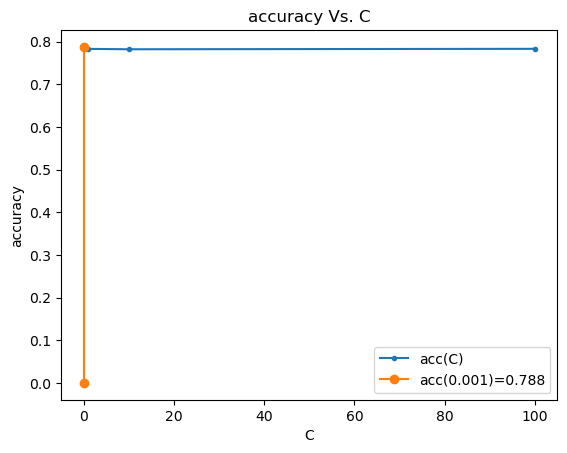

In [9]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 30
C_array = np.array([0.001, 0.01, 0.1, 1, 10, 100])
param = 'C'
model = LogisticRegression()
acc_total = np.array([])

for val in C_array:
    acc = np.array([])
    model.set_params(C = val)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(C_array,acc_total,'.-')
plt.plot([C_array[acc_total.argmax()],C_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({C_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

## Optimum parameters check

In [13]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 40
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    clf = LogisticRegression(C=0.001).fit(X_train,Y_train)
    acc = np.append(acc,clf.score(X_test,Y_test))
acc.mean()

0.7838945172824792

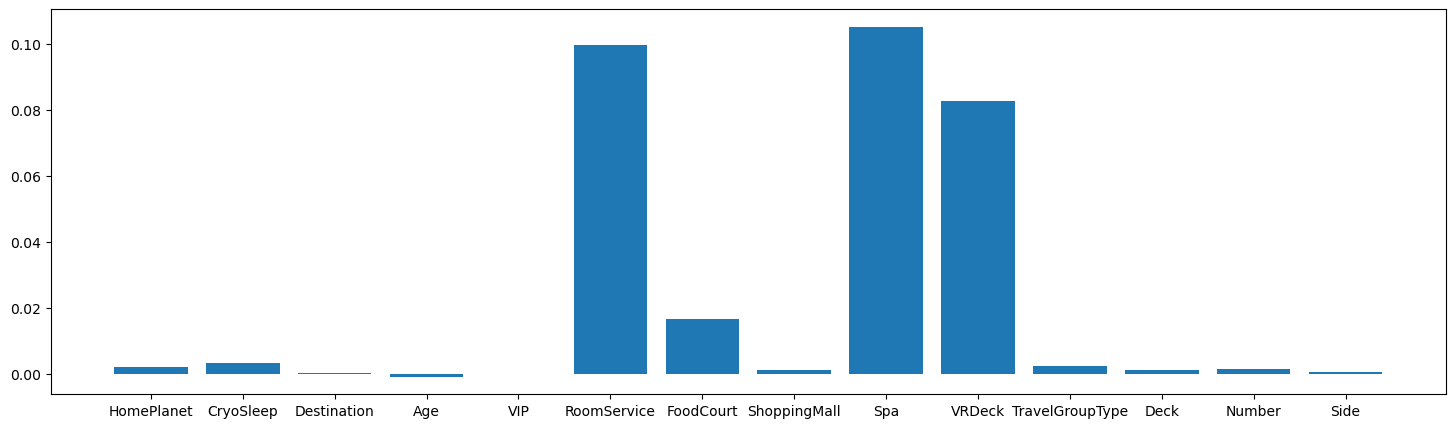

In [17]:
from sklearn.inspection import permutation_importance
result = permutation_importance(clf, X_test, Y_test, n_repeats=20, random_state=42)
importances = result.importances_mean
feature_names = GetFeatureNames("X_data.csv")

plt.figure(figsize=(18,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.show()